<a href="https://colab.research.google.com/github/MehdiSaraeian/Classification/blob/add-workshop-scenarios/scenarios/05-neural-networks/Scenario_5_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 5: The Deep Dive: A Gentle Introduction to Neural Networks

Let's step into the world of deep learning! We'll build a simple Neural Network using TensorFlow and Keras to tackle our classification problem. We'll also learn to monitor the training process and prevent overfitting.

## 1. Import Libraries and Prepare Data

We'll need the `tensorflow` library for this. Feature scaling is also very important for neural networks.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# --- Data Prep ---
column_names = [
    'id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape',
    'marg_adhesion', 'single_epith_cell_size', 'bare_nuclei',
    'bland_chrom', 'norm_nucleoli', 'mitoses', 'class'
]
df = pd.read_csv('/content/breast-cancer-wisconsin.data', names=column_names)
df['bare_nuclei'] = df['bare_nuclei'].replace('?', np.nan)
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'])
df['bare_nuclei'] = df['bare_nuclei'].fillna(df['bare_nuclei'].median())
df.drop('id', axis=1, inplace=True)
df['class'] = df['class'].map({2: 0, 4: 1})
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. Build the Neural Network Model

We'll create a `Sequential` model, which is a simple stack of layers. Our model will have:
- An input layer
- Two hidden layers with the `relu` activation function
- A `Dropout` layer for regularization
- An output layer with a `sigmoid` activation function for our binary classification task.

In [2]:
from tensorflow.keras.layers import Input
from tensorflow.keras.regularizers import l1_l2

# HINT: Use `Sequential` to create the model. Add `Dense` layers for the neurons.
# The first layer needs an `input_shape` argument: `(X_train.shape[1],)`

# YOUR CODE HERE
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Using Input layer as recommended
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Print a summary of the model's architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Compile the Model

Before we can train the model, we need to configure the learning process. We do this with the `compile` method, where we specify the optimizer, the loss function, and any metrics we want to track.

In [3]:
# HINT: For binary classification, a good choice is optimizer='adam', loss='binary_crossentropy', and metrics=['accuracy'].

# YOUR CODE HERE
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 4. Train the Model with Early Stopping

We'll train the model using the `.fit()` method. We'll also use an `EarlyStopping` callback to monitor the validation loss and stop training automatically when the model stops improving, which helps prevent overfitting.

In [4]:
# HINT: Create an EarlyStopping callback monitoring 'val_loss'.
# Then, call model.fit(), passing in the training data, validation_split=0.2, epochs, and the callback.

# YOUR CODE HERE
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7409 - loss: 0.6019 - val_accuracy: 0.9643 - val_loss: 0.4817
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9523 - loss: 0.4430 - val_accuracy: 0.9643 - val_loss: 0.3696
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9742 - loss: 0.3515 - val_accuracy: 0.9643 - val_loss: 0.2825
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9760 - loss: 0.2525 - val_accuracy: 0.9643 - val_loss: 0.2177
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9743 - loss: 0.1949 - val_accuracy: 0.9643 - val_loss: 0.1718
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9660 - loss: 0.1818 - val_accuracy: 0.9643 - val_loss: 0.1418
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9814 - loss: 0.1271 - val_accuracy: 0.9643 - val_loss: 0.1222
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9726 - loss: 0.1197 - val_accuracy: 0.9643 -

## 5. Visualize Training History

Plotting the training and validation loss/accuracy over epochs is a great way to see how your model learned and whether it overfitted.

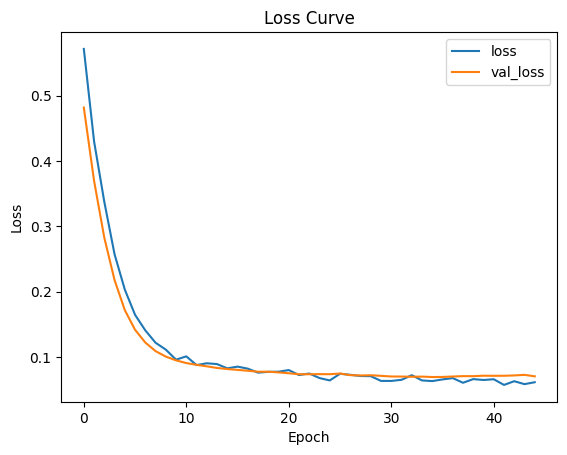

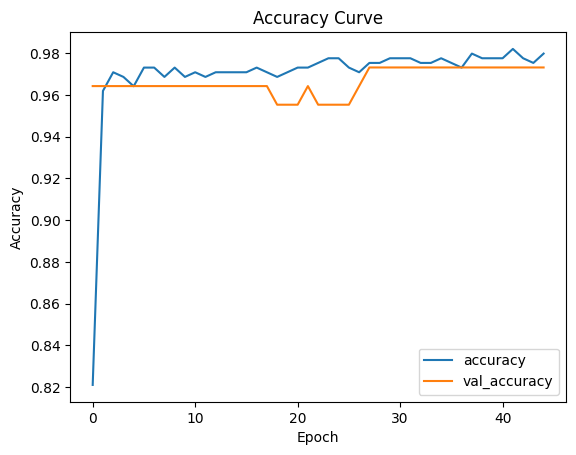

In [5]:
history_df = pd.DataFrame(history.history)

# Plot Loss
history_df.loc[:, ['loss', 'val_loss']].plot(title="Loss Curve")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Plot Accuracy
history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy Curve")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## 6. Evaluate the Final Model

Finally, let's evaluate our trained model on the unseen test set.

In [6]:
# HINT: Use model.predict() on the test set. Since the output is a probability, you'll need to round it to get the final class (0 or 1).

# YOUR CODE HERE
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

print("\n--- Neural Network Evaluation on Test Set ---")
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

--- Neural Network Evaluation on Test Set ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        92
           1       0.94      0.96      0.95        48

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



## 7. Visualize Confusion Matrix and ROC Curve

Let's visualize the confusion matrix and ROC curve to get a better understanding of our model's performance on the test set.

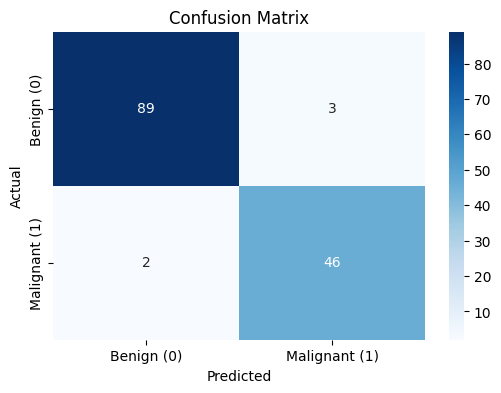

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


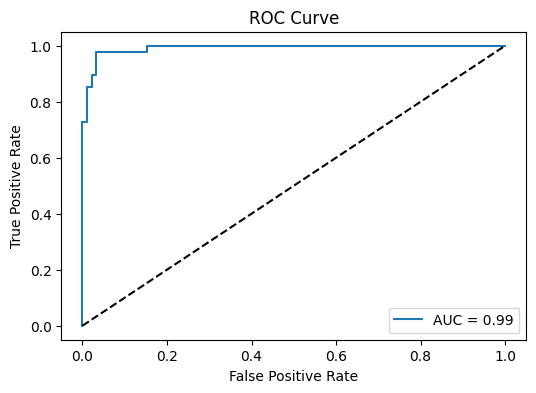

In [7]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve and AUC
y_pred_probs = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
auc = roc_auc_score(y_test, y_pred_probs)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Define the hyperparameter search space

Determine the range of values to explore for each hyperparameter (e.g., number of neurons, dropout rate, learning rate).


In [8]:
param_grid = {
    'dense_1_neurons': [16, 32, 64],
    'dense_2_neurons': [8, 16, 32],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [0.01, 0.001, 0.0001]
}

## Implement the tuning process

Choose a hyperparameter tuning method and implement the tuning process. For this, we'll use Keras Tuner, a library that makes it easy to tune hyperparameters for Keras models.


Import the keras_tuner library and define the build_model function and instantiate the RandomSearch tuner to prepare for hyperparameter tuning.



In [9]:
!pip install keras_tuner

In [10]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(units=hp.Int('dense_1_neurons', min_value=16, max_value=64, step=16),
                    activation='relu',
                    kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
    model.add(Dropout(hp.Choice('dropout_rate', values=[0.1, 0.2, 0.3])))
    model.add(Dense(units=hp.Int('dense_2_neurons', min_value=8, max_value=32, step=8),
                    activation='relu',
                    kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
    model.add(Dense(1, activation='sigmoid'))

    learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='keras_tuner_dir',
    project_name='breast_cancer_nn_tuning')

Reloading Tuner from keras_tuner_dir/breast_cancer_nn_tuning/tuner0.json


Run the hyperparameter search using the instantiated tuner object and the training data, including validation split, epochs, and the early stopping callback.



In [11]:
tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

## Evaluate the Best Model on the Test Set

Get the best model from the tuner and use the `evaluate` method to assess its performance on the test data.

In [12]:
# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Get the best hyperparameters to re-compile the model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
learning_rate = best_hps.get('learning_rate')

# Re-compile the best model with the best hyperparameters
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])


# Evaluate the best model on the test set
print("\n--- Best Model Evaluation on Test Set ---")
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate classification report for the best model
y_pred_probs_best = best_model.predict(X_test)
y_pred_best = (y_pred_probs_best > 0.5).astype("int32")

print("\n--- Best Model Classification Report ---")
print(classification_report(y_test, y_pred_best))

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



--- Best Model Evaluation on Test Set ---
Test Loss: 0.2203
Test Accuracy: 0.9643
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

--- Best Model Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        92
           1       0.94      0.96      0.95        48

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



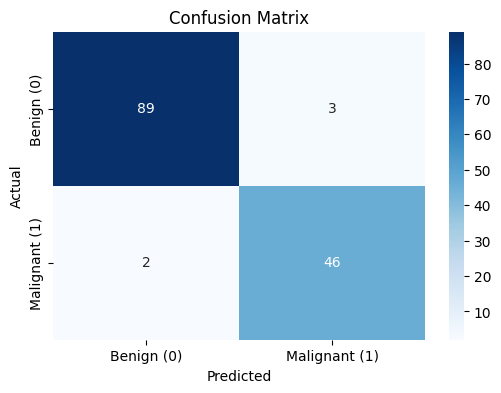

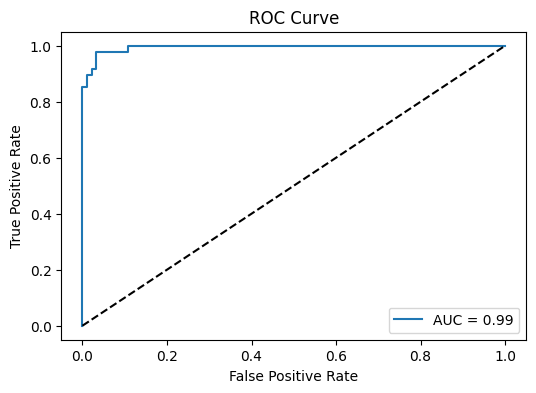

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs_best)
auc = roc_auc_score(y_test, y_pred_probs_best)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()